In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
PROJECT_ROOT = Path("..")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "RQ3"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
summary = pd.read_parquet(
    PROCESSED_DIR
    / "08_pairwise_centroid_similarity"
    / "pairwise_centroid_similarity_temporal_summary.parquet"
)

summary.head()

,modality,window_start,window_end,n_valid_pairs,mean_cosine_similarity,median_cosine_similarity,std_cosine_similarity,q25_cosine_similarity,q75_cosine_similarity,mean_cosine_distance,median_cosine_distance,n_valid_genres
0,essentia,1955,1959,6,-0.227473,-0.310406,0.418132,-0.510697,0.100295,1.227473,1.310406,4
1,essentia,1956,1960,21,0.006022,0.107410,0.432719,-0.388253,0.388426,0.993978,0.892590,7
2,essentia,1957,1961,15,-0.057477,-0.033687,0.403970,-0.456428,0.243134,1.057477,1.033687,6
3,essentia,1958,1962,21,-0.030452,0.054845,0.387582,-0.340264,0.202108,1.030452,0.945155,7
4,essentia,1959,1963,21,-0.098551,-0.109990,0.345279,-0.318558,0.061982,1.098551,1.109990,7


In [5]:
trend_rows = []

for modality, modality_data in summary.groupby("modality"):
    modality_data = modality_data.sort_values("window_start")

    trend_rows.append({
        "modality": modality,
        "n_windows": len(modality_data),
        "spearman_year_similarity": modality_data[
            "window_start"
        ].corr(
            modality_data["median_cosine_similarity"],
            method="spearman"
        ),
        "pearson_year_similarity": modality_data[
            "window_start"
        ].corr(
            modality_data["median_cosine_similarity"],
            method="pearson"
        ),
        "spearman_year_distance": modality_data[
            "window_start"
        ].corr(
            modality_data["median_cosine_distance"],
            method="spearman"
        ),
        "spearman_similarity_genres": modality_data[
            "median_cosine_similarity"
        ].corr(
            modality_data["n_valid_genres"],
            method="spearman"
        ),
        "spearman_similarity_pairs": modality_data[
            "median_cosine_similarity"
        ].corr(
            modality_data["n_valid_pairs"],
            method="spearman"
        ),
    })

trend_summary = pd.DataFrame(trend_rows)

trend_summary

,modality,n_windows,spearman_year_similarity,pearson_year_similarity,spearman_year_distance,spearman_similarity_genres,spearman_similarity_pairs
0,essentia,65,0.315253,0.302681,-0.315253,0.287441,0.287441
1,lyrics_tf_idf,65,0.977360,0.755452,-0.977360,0.954429,0.954429
2,mfcc,65,0.442614,0.286156,-0.442614,0.394259,0.394259
3,musicnn,65,0.482736,-0.116768,-0.482736,0.489468,0.489468
4,vgg19,65,0.777142,0.739888,-0.777142,0.816919,0.816919
5,word2vec,65,0.197727,-0.305117,-0.197727,0.178678,0.178678


- **Lyrics TF-IDF:** very strong increase in similarity over time; also very strongly linked to growing genre coverage
- **VGG19:** strong increase in similarity; coverage relationship also strong
- **MusicNN:** moderate monotonic increase, but negative Pearson suggests a nonlinear trend or strong early/late effects
- **MFCC:** moderate increase in similarity
- **Essentia:** weak-to-moderate increase in similarity
- **Word2Vec:** weak monotonic trend; Pearson suggests the overall pattern is not consistently increasing
- **Overall:** centroid-based genre similarity tends to increase rather than decrease
- **Caution:** similarity is positively correlated with the number of valid genres, especially for Lyrics TF-IDF and VGG19

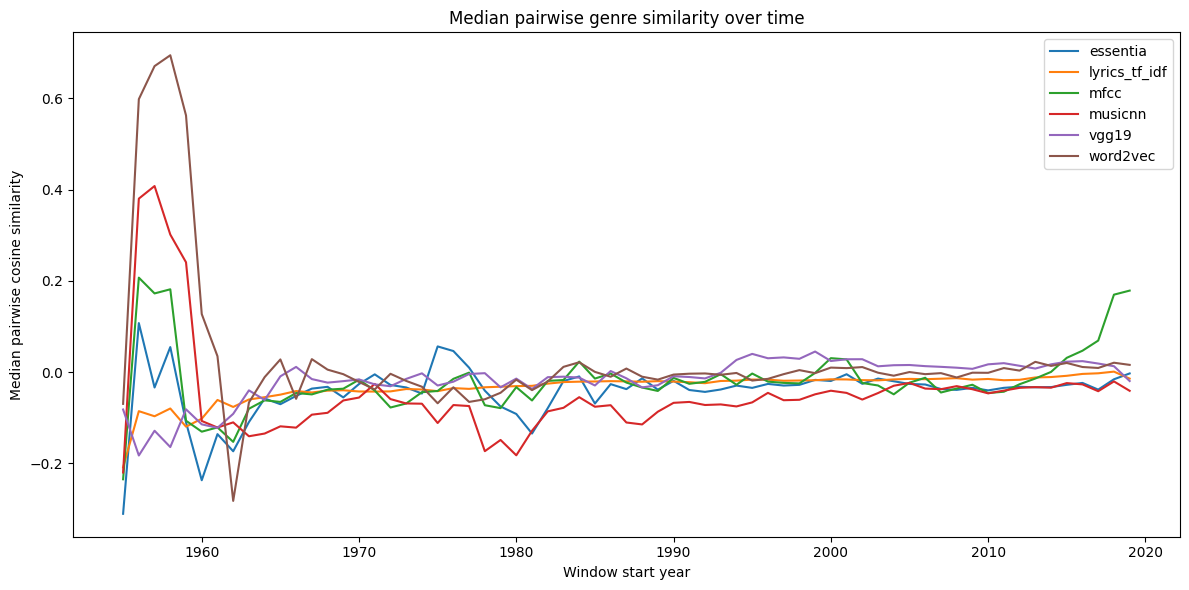

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for modality, modality_data in summary.groupby("modality"):
    plt.plot(
        modality_data["window_start"],
        modality_data["median_cosine_similarity"],
        label=modality
    )

plt.xlabel("Window start year")
plt.ylabel("Median pairwise cosine similarity")
plt.title("Median pairwise genre similarity over time")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq3_median_pairwise_genre_similarity_over_time.pdf",
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq3_median_pairwise_genre_similarity_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

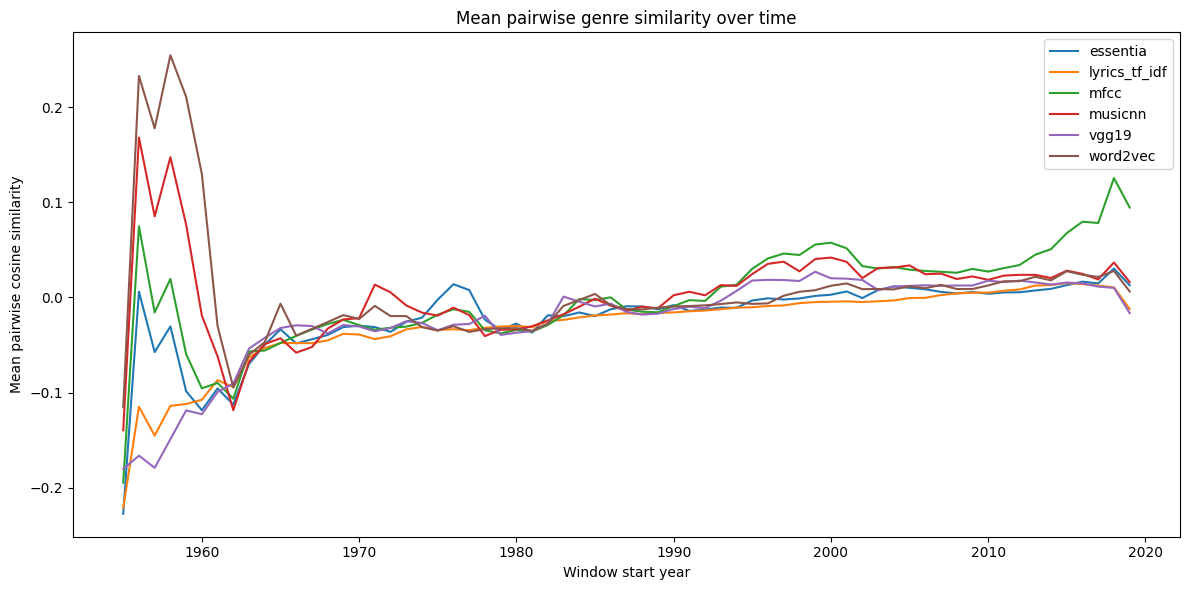

In [7]:
plt.figure(figsize=(12, 6))

for modality, modality_data in summary.groupby("modality"):
    plt.plot(
        modality_data["window_start"],
        modality_data["mean_cosine_similarity"],
        label=modality
    )

plt.xlabel("Window start year")
plt.ylabel("Mean pairwise cosine similarity")
plt.title("Mean pairwise genre similarity over time")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq3_mean_pairwise_genre_similarity_over_time.pdf",
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq3_mean_pairwise_genre_similarity_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

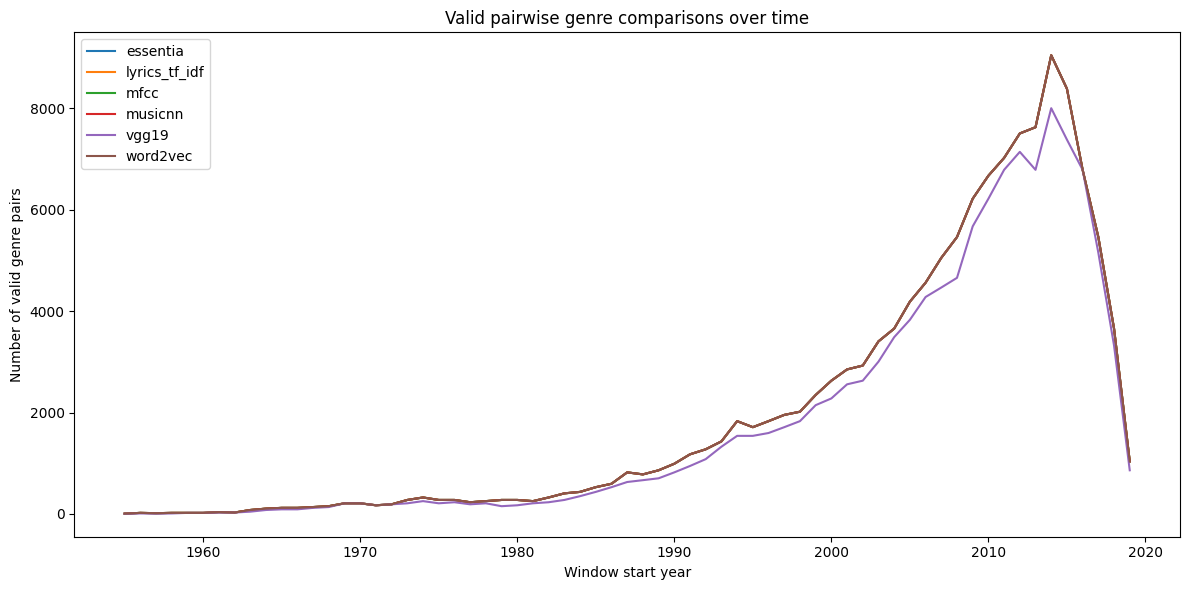

In [8]:
plt.figure(figsize=(12, 6))

for modality, modality_data in summary.groupby("modality"):
    plt.plot(
        modality_data["window_start"],
        modality_data["n_valid_pairs"],
        label=modality
    )

plt.xlabel("Window start year")
plt.ylabel("Number of valid genre pairs")
plt.title("Valid pairwise genre comparisons over time")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq3_valid_genre_pairs_over_time.pdf",
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq3_valid_genre_pairs_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The analysis uses genre centroids from **within-period z-normalized features** across Essentia, Lyrics TF-IDF, MFCC, MusicNN, VGG19, and Word2Vec. Cosine similarity is calculated between all valid genre pairs within each five-year window.

- The **mean similarity** generally increases over time, suggesting a modest tendency toward genre convergence.
- The **median similarity** stays close to zero, indicating that the typical genre pair does not become strongly more similar.
- The difference between mean and median suggests that convergence is driven by only some genre pairs. (further analysis which genre will follow)
- Early and final windows are less reliable because they contain fewer valid genre pairs.

Overall, the results show **weak, modality-specific convergence rather than a strong universal trend**.